## A notebook for testing the seir equations with a forward Euler and a Monte Carlo model.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colors
from IPython.display import HTML
from matplotlib.animation import FuncAnimation
import matplotlib.patches as mpatches
import monte_carlo.seir_monte_carlo as mc
import forward_euler.seir_forward_euler as f

### Input Parameters

In [2]:
shared_parameters = {
    "s_0": 0.95,
    "e_0": 0.05,
    "i_0": 0.0,
    "r_0": 0.0,
    "beta": 1.0,
    "sigma": 0.1,
    "gamma": 0.005
}

# Forward Euler parameters
step = 0.1
t_final = 100
f_euler_output = "f_euler_seir_data.csv"

# Monte Carlo parameters
length = 100
agent_count = 250
MCS = 2000
mc_seir_output = "mc_seir_data.csv"
mc_lattice_output = "mc_lattice_data.csv"

### Forward Euler simulation

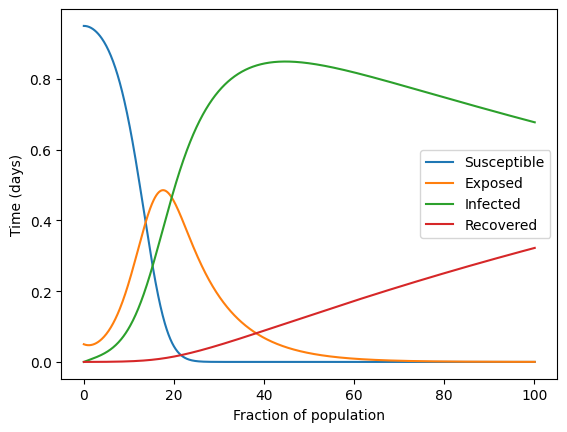

In [3]:
f.forward_euler(**shared_parameters, step=step, t_final=t_final, seir_filename=f_euler_output)
f_euler_df = pd.read_csv(f_euler_output)

fig, ax = plt.subplots()

seir_labels = ["Susceptible", "Exposed", "Infected", "Recovered"]

for label in seir_labels:
    ax.plot(f_euler_df.iloc[:,0], f_euler_df[label.lower()], label=label) # Plotting each population category on the same ax

ax.set_xlabel("Fraction of population")
ax.set_ylabel("Time (days)")
ax.legend()

plt.show()

### Monte Carlo simulation

In [4]:
sim = mc.System(**shared_parameters, length=length, agent_count=agent_count)
sim.run_sim(MCS=MCS, seir_filename=mc_seir_output, lattice_filename=mc_lattice_output) # Initialising and running sim
mc_seir_df = pd.read_csv(mc_seir_output)

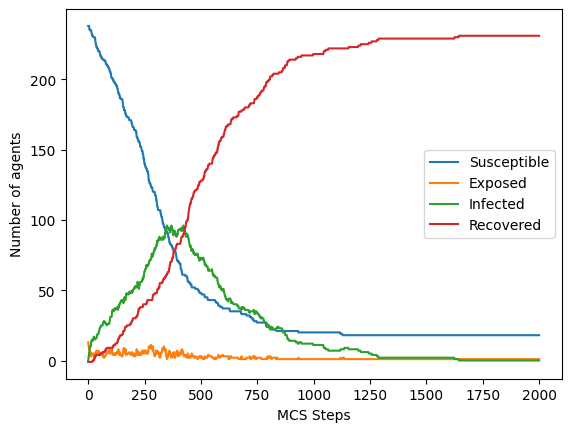

In [5]:
fig, ax = plt.subplots()

seir_labels = ["susceptible", "exposed", "infected", "recovered"]

for label in seir_labels:
    ax.plot(mc_seir_df.iloc[:,0], mc_seir_df[label], label=label.capitalize()) # Plotting each population category on the same ax

ax.set_xlabel("MCS Steps")
ax.set_ylabel("Number of agents")
ax.legend()

plt.show()

In [ ]:
%matplotlib notebook

mc_lattice_df = pd.read_csv(mc_lattice_output)

lattices_1d = mc_lattice_df.iloc[:, 1].to_list()
lattices_2d = []

for l in lattices_1d:
    temp = np.array(l.split(), dtype=int)
    l_2d = np.reshape(temp, (length, length))
    lattices_2d.append(l_2d)

fig, ax = plt.subplots(dpi=100)

my_colors = ['white', 'tab:blue', 'tab:orange', 'tab:green', 'tab:red']
cmap = colors.ListedColormap(my_colors)
norm = colors.NoNorm()

ax.set_xlabel("X Position")
ax.set_ylabel("Y Position")

image = ax.imshow(lattices_2d[0], interpolation='none', cmap=cmap, norm=norm, animated=True, extent=[0, length, length, 0])

patches = [mpatches.Patch(color=my_colors[j+1], label=(seir_labels[j-1]).capitalize()) for j in range(4)]
ax.legend(handles=patches, loc=1, bbox_to_anchor=(1.37, 0.7), frameon=False)

def update(frame):
    image.set_data(lattices_2d[frame])
    return [image]

animation = FuncAnimation(
    fig,
    update,
    frames=len(lattices_2d),
    interval=50,
    blit=True
)

HTML(animation.to_jshtml())

<IPython.core.display.Javascript object>